## profil_age_series_bofip

**Fichier(s) source :** `./data/inventaire_bofip_stock_live_20260521.csv` (inventaire produit par `profilage_bofip_consolide.ipynb`)

**Fichier(s) de sortie :** `age_stock.png` et `series_stock.png` (figures)

**Description :** Deux figures à partir de l'inventaire du stock BOFiP : répartition des documents par année de publication (profil d'âge) et répartition par série (les quinze premières), avec quelques chiffres clés.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

CSV = r"./data/inventaire_bofip_stock_live_20260521.csv"

df = pd.read_csv(CSV)
print(f"Documents chargés : {len(df)}")

Documents chargés : 6311


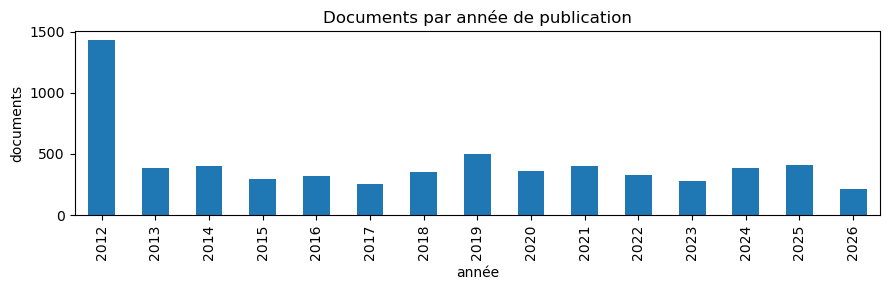


Année 2012 : 1430 documents
Part de 2012 : 22.7%
Publiés avant 2020 : 3937 (62.4%)


In [2]:
# === Figure 1 : Documents par année de publication ===
annees = df["annee"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 3))
annees.plot(kind="bar", ax=ax)
ax.set_title("Documents par année de publication")
ax.set_ylabel("documents")
ax.set_xlabel("année")
plt.tight_layout()
plt.savefig("age_stock.png", dpi=110)
plt.show()

# Chiffres clés
an = pd.to_numeric(df["annee"], errors="coerce")
print(f"\nAnnée 2012 : {annees.get('2012', annees.get(2012, 0))} documents")
print(f"Part de 2012 : {annees.get('2012', annees.get(2012, 0)) / len(df):.1%}")
avant_2020 = int((an < 2020).sum())
print(f"Publiés avant 2020 : {avant_2020} ({avant_2020/len(df):.1%})")

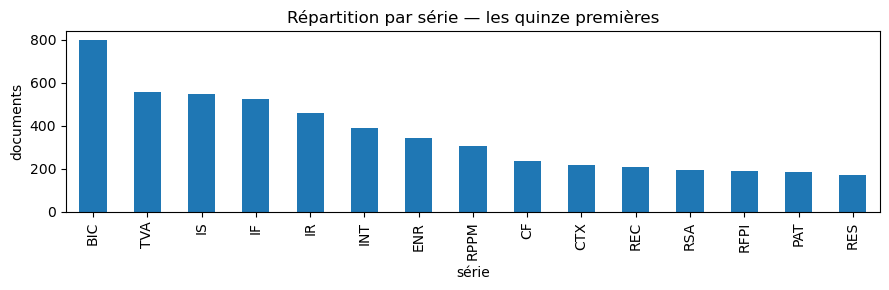


Nombre de séries : 29
Série la plus fournie : BIC (799 documents)
Série la moins fournie : DAE (5 documents)


In [3]:
# === Figure 2 : Répartition par série (top 15) ===
series = df["serie"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(9, 3))
series.plot(kind="bar", ax=ax)
ax.set_title("Répartition par série — les quinze premières")
ax.set_ylabel("documents")
ax.set_xlabel("série")
plt.tight_layout()
plt.savefig("series_stock.png", dpi=110)
plt.show()

# Chiffres clés
print(f"\nNombre de séries : {df['serie'].nunique()}")
print(f"Série la plus fournie : {series.index[0]} ({series.iloc[0]} documents)")
print(f"Série la moins fournie : {df['serie'].value_counts().index[-1]} ({df['serie'].value_counts().iloc[-1]} documents)")